<a href="https://colab.research.google.com/github/Prakruthi2606/House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Price Prediction (Regression)**

### **Problem Statement**:
The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a **Machine Learning regression model**
that predicts the **price of a house** using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

### **Steps / Objective**:
* Understand and **explore** the housing dataset.
* Perform **data preprocessing** including handling missing values, duplicates, and outliers.
* Conduct **Exploratory Data Analysis (EDA)** to identify patterns and relationships in the
data.
* Apply **encoding, log transformation, and feature scaling** where necessary.
* Train multiple **regression** algorithms to predict house prices.
* Evaluate and compare model performance using appropriate **evaluation metrics**.

### **Domain Analysis**:
**1. Square_Footage**

* Description: Total area of the house measured in square feet.

* Data Type: Continuous Numerical (int64)

**2. Num_Bedrooms**

* Description: Number of bedrooms available in the house.

* Data Type: Discrete Numerical (int64)

**3. Num_Bathrooms**

* Description: Number of bathrooms present in the house.

* Data Type: Discrete Numerical (int64)

**4. Year_Built**

* Description: The year in which the house was constructed.

* Data Type: Discrete Numerical (int64)

**5. Lot_Size**

* Description: Total land area on which the house is built.

* Data Type: Continuous Numerical (float64)

**6. Garage_Size**

* Description: Number of vehicles that can be accommodated in the garage.

* Data Type: Discrete Numerical (int64)

**7. Neighborhood_Quality**

* Description: Rating that represents the quality of the neighborhood where the house is located.

* Data Type: Discrete Numerical / Ordinal Data (int64)

**8. House_Price**

* Description: Selling price of the house.

* Data Type: Continuous Numerical (float64)

Hence from the above domain analysis this is the **insight**:
* **Input features (X):**  Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size, Garage_Size, Neighborhood_Quality

* **Target variable (y):** House_Price

### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,mean_squared_log_error

### **Load Data**

In [ ]:
df = pd.read_csv('house_price_regression_dataset.csv')
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### **Basic Checks**

In [ ]:
# to know the number of rows and columns
df.shape

(1000, 8)

In [ ]:
# to know the names of columns
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
# to know the data types of columns
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


**Important Insight:** all the coulmns in the dataset is numerical

In [ ]:
# to print 1st 5 rows
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# to print last 5 rows
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
# to know memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
# to know statestical report of the columns
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


### **Data Cleaning**

In [ ]:
# check for null values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [ ]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

**Insight:** there are no null/missing values and no duplicate values in the dataset

### **Exploratory data analysis (EDA):**

Univariate analysis:

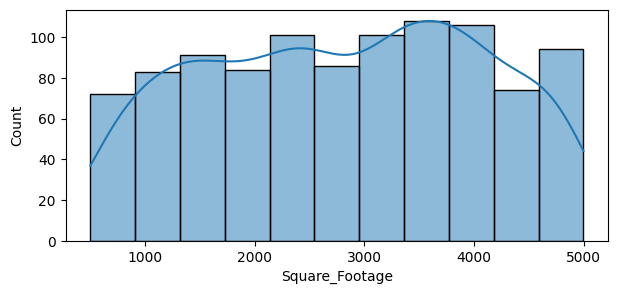

In [ ]:
# check the distribution of Square_Footage
plt.figure(figsize=(7,3))
sns.histplot(df,x='Square_Footage',kde=True)
plt.show()

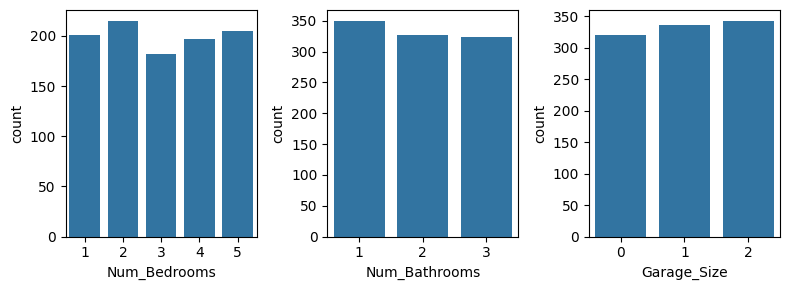

In [ ]:
# check the distribution of Num_Bedrooms, Num_Bathrooms and Garage_Size
fig,ax=plt.subplots(1,3,figsize=(8,3))
sns.countplot(df,x='Num_Bedrooms', ax=ax[0])
sns.countplot(df,x='Num_Bathrooms', ax=ax[1])
sns.countplot(df,x='Garage_Size', ax=ax[2])
plt.tight_layout()

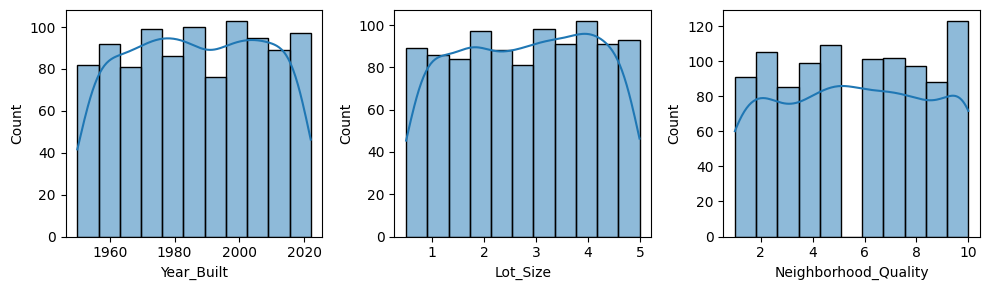

In [ ]:
# check the distribution of Year_Built, Lot_Size and Neighborhood_Quality
fig,ax=plt.subplots(1,3,figsize=(10,3))
sns.histplot(df,x='Year_Built',kde=True, ax=ax[0])
sns.histplot(df,x='Lot_Size',kde=True, ax=ax[1])
sns.histplot(df,x='Neighborhood_Quality',kde=True, ax=ax[2])
plt.tight_layout()

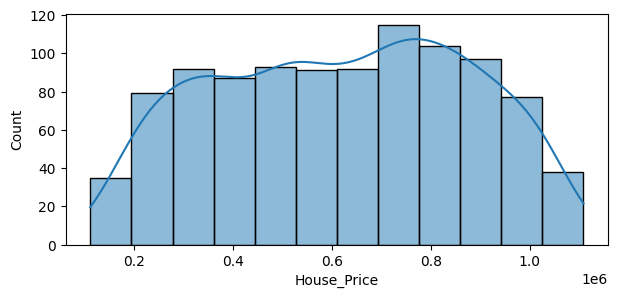

In [ ]:
# check the distribution of House_Price
plt.figure(figsize=(7,3))
sns.histplot(df,x='House_Price',kde=True)
plt.show()

**Usefull Insights:**
* Square_Footage and House_Price show a wide range of values, indicating high variability in house sizes and prices.
* Most houses have 2 bedrooms 1 bathrooms.

### **Bivariate Analysis:**

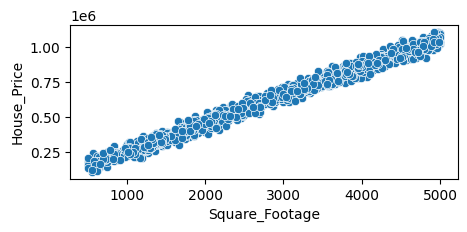

In [ ]:
#find relationship between Square_Footage vs House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Square_Footage',y='House_Price')
plt.show()

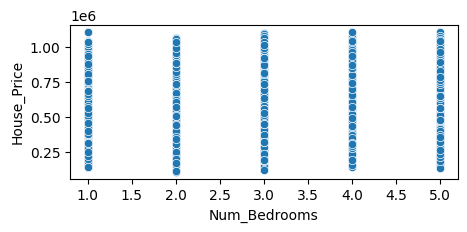

In [ ]:
#find relationship between Num_Bedrooms vs House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Num_Bedrooms',y='House_Price')
plt.show()

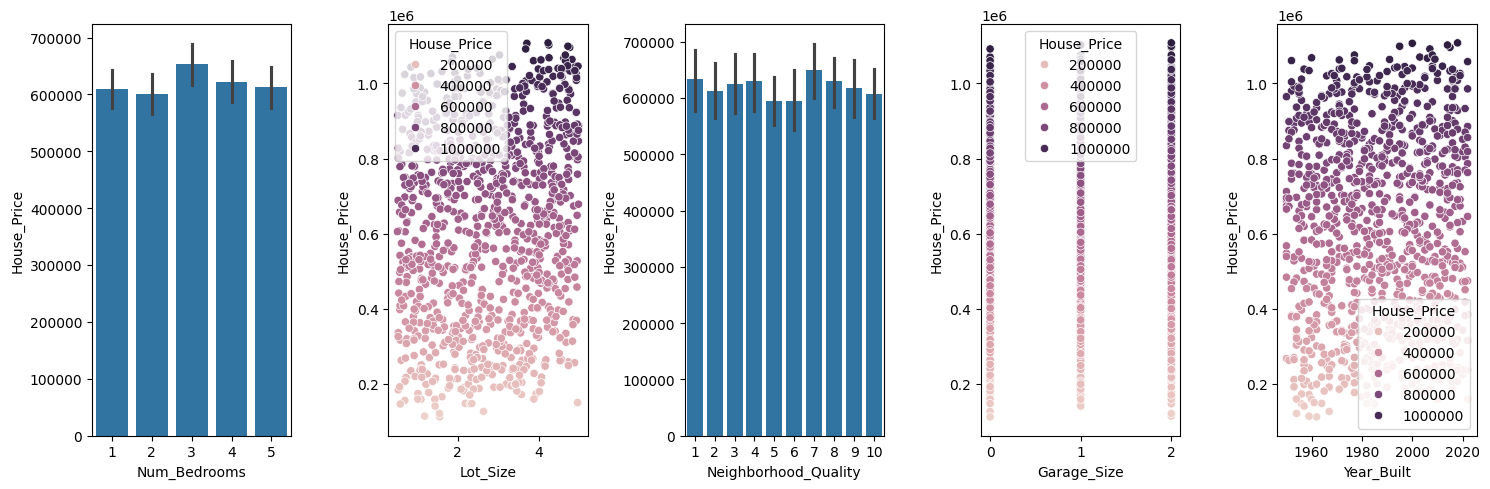

In [ ]:
#find relationship between all other columns vs House_Price
fig,ax=plt.subplots(1,5,figsize=(15,5))
sns.barplot(df,x='Num_Bedrooms',y='House_Price',ax=ax[0])
sns.scatterplot(df,x='Lot_Size',y='House_Price', hue= 'House_Price', ax=ax[1])
sns.barplot(df,x='Neighborhood_Quality',y='House_Price', ax=ax[2])
sns.scatterplot(df,x='Garage_Size',y='House_Price', hue= 'House_Price', ax=ax[3])
sns.scatterplot(df,x='Year_Built',y='House_Price', hue= 'House_Price', ax=ax[4])
plt.tight_layout()

**usful insights:**
* There is a positive relationship between Square_Footage and House_Price — larger houses generally have higher prices.
* Neighborhood_Quality and House_Price are positively related — houses in better neighborhoods tend to have higher prices.

### **Multivariate analysis:**

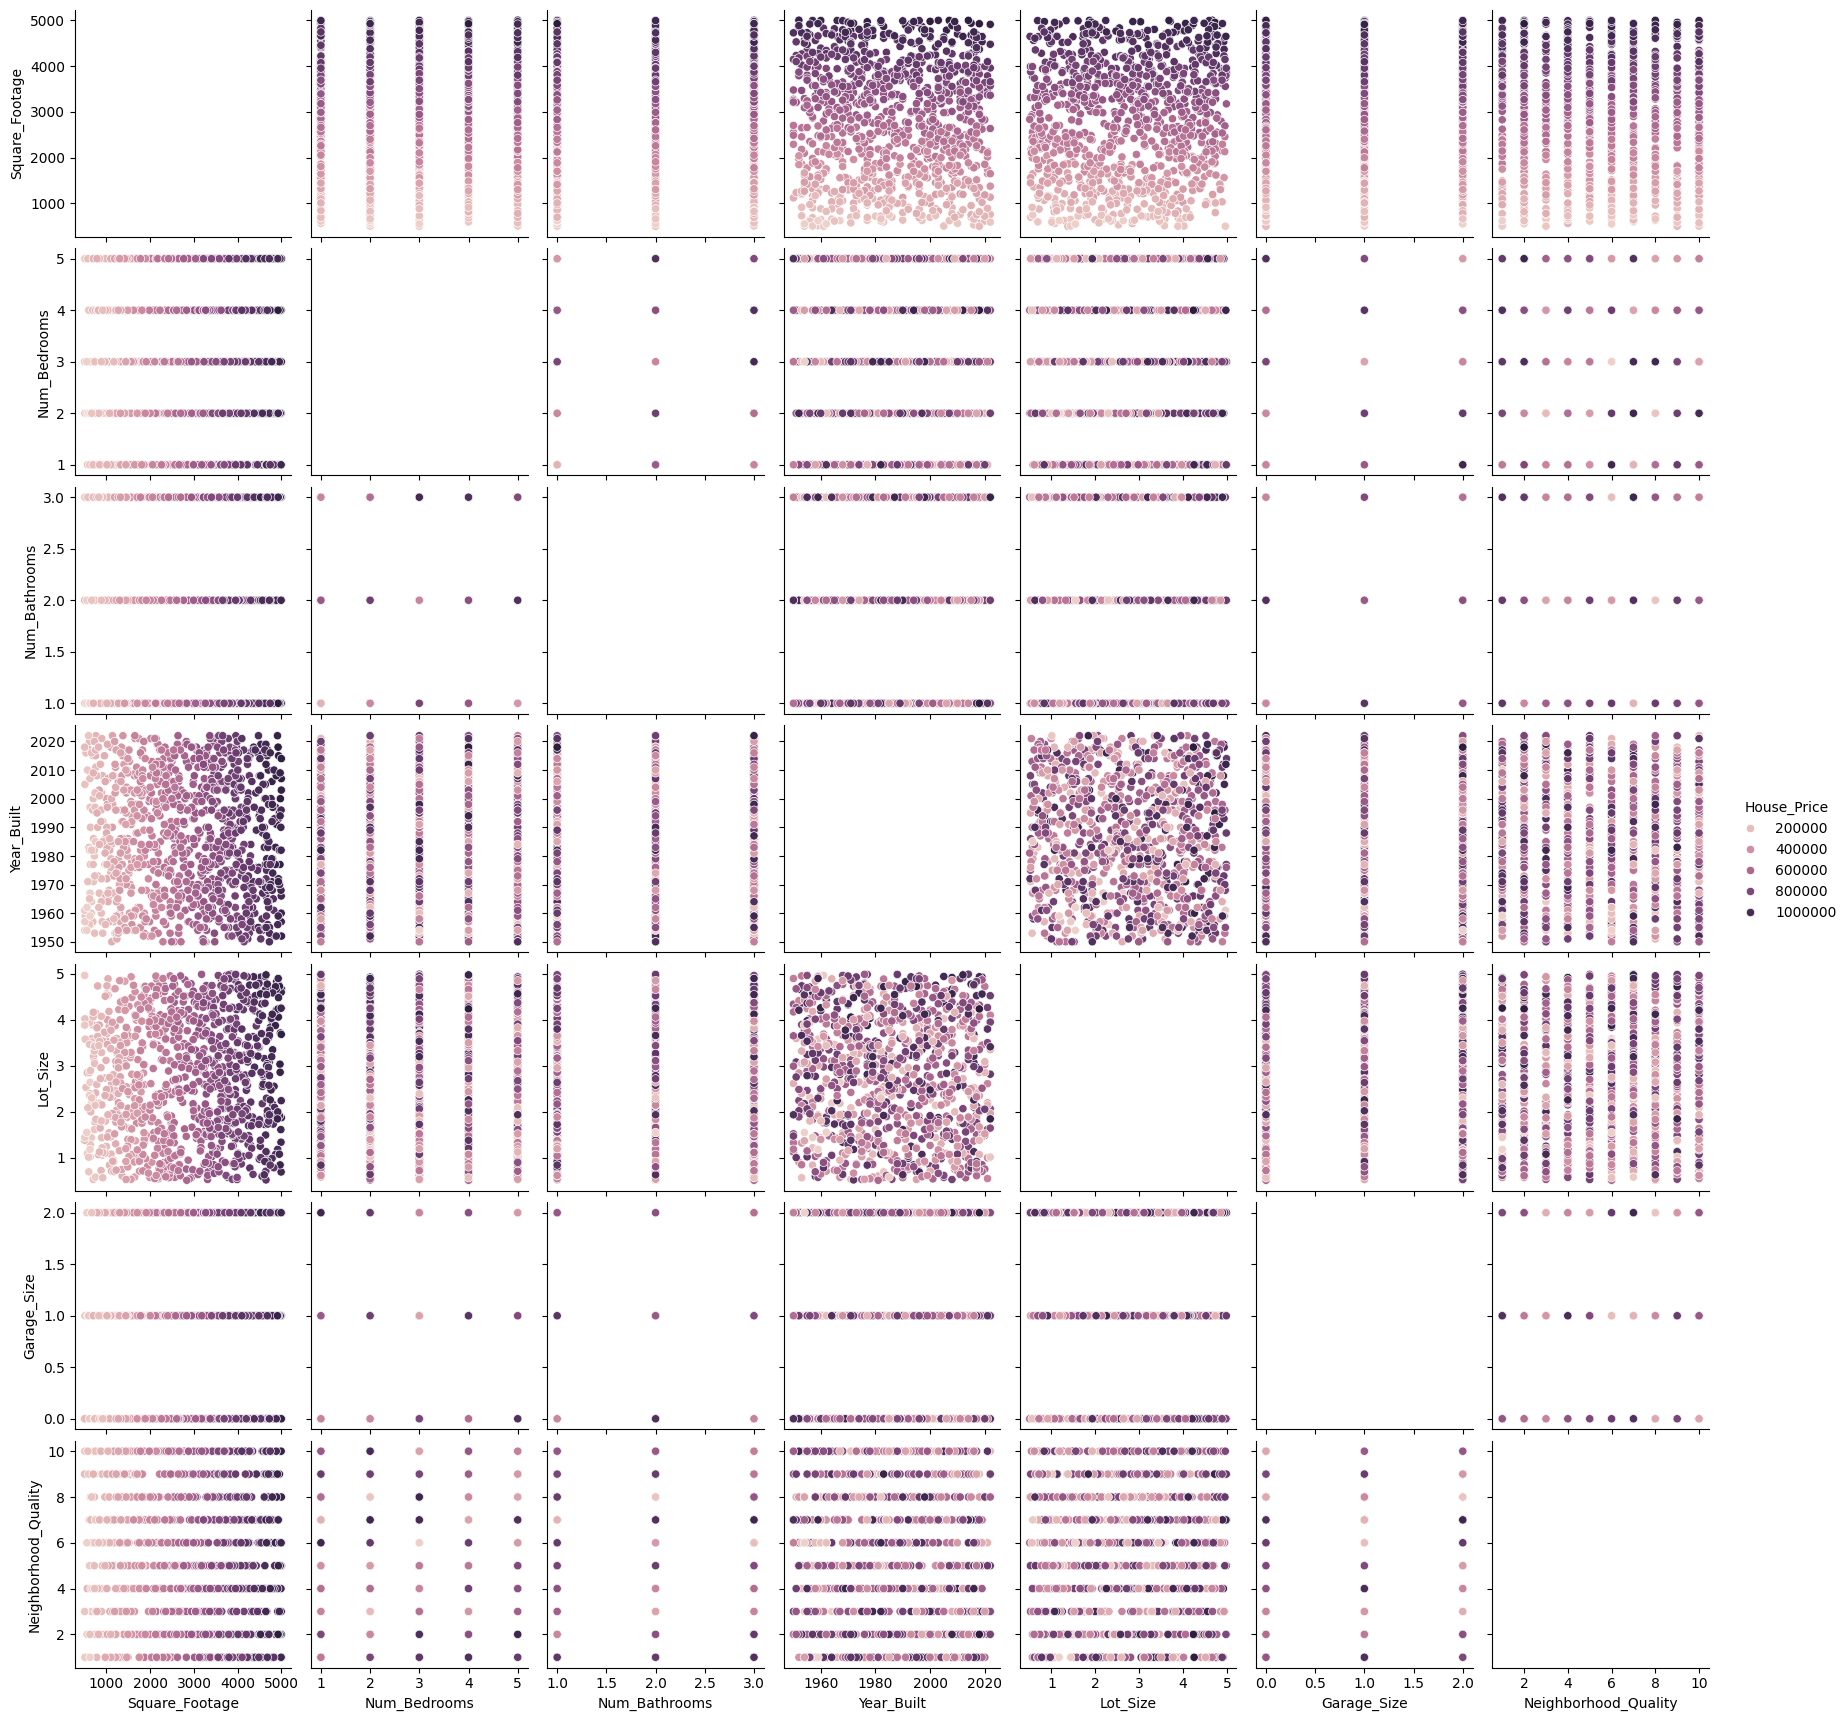

In [ ]:
#pairplot
sns.pairplot(df, hue='House_Price')

**Note:**
* When two discrete variables are plotted against each other, many points overlap on the same coordinate.
So it looks like the plot is empty or has very few points, but actually many points are stacked on top of each other.
* The pairplot shows that Square_Footage and Lot_Size have visible relationships with House_Price, while discrete variables such as Num_Bedrooms and Num_Bathrooms form clustered patterns due to limited value ranges.

In [ ]:
#Heatmap
df.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


<Axes: >

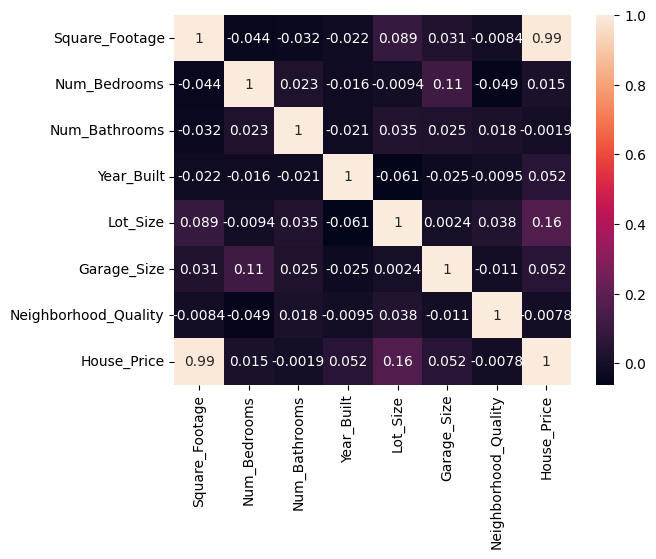

In [ ]:
sns.heatmap(df.corr(),annot = True)

**useful insights:**
* Shows close relativity among Square_Footage and House_Price
* Houses with large Square_Footage tend to have the highest prices.


### **Handling Outliers**

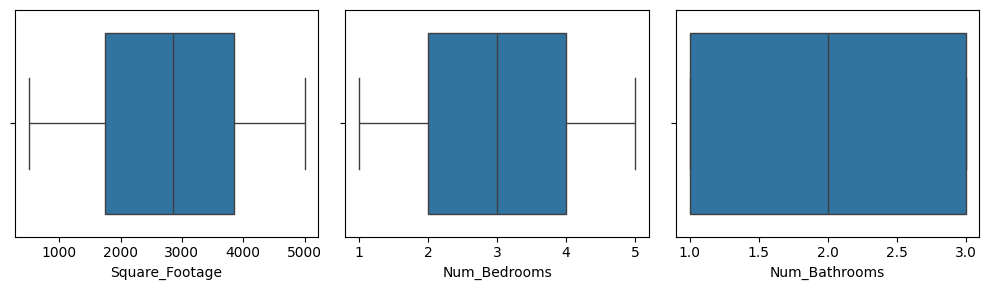

In [ ]:
#checking for outliers
fig,ax=plt.subplots(1,3,figsize=(10,3))
sns.boxplot(df,x='Square_Footage',ax=ax[0])
sns.boxplot(df,x='Num_Bedrooms',ax=ax[1])
sns.boxplot(df,x='Num_Bathrooms',ax=ax[2])
plt.tight_layout()

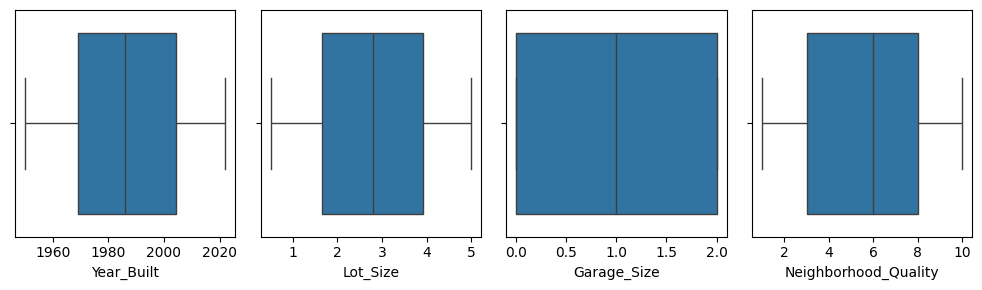

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(10,3))
sns.boxplot(df,x='Year_Built',ax=ax[0])
sns.boxplot(df,x='Lot_Size',ax=ax[1])
sns.boxplot(df,x='Garage_Size',ax=ax[2])
sns.boxplot(df,x='Neighborhood_Quality',ax=ax[3])
plt.tight_layout()

**Note:** There are no outliers

### **Scaling**

In [ ]:
# standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df[['Square_Footage']] = scaler.fit_transform(df[['Square_Footage']])
df[['Num_Bedrooms']] = scaler.fit_transform(df[['Num_Bedrooms']])
df[['Num_Bathrooms']] = scaler.fit_transform(df[['Num_Bathrooms']])
df[['Year_Built']] = scaler.fit_transform(df[['Year_Built']])
df[['Lot_Size']] = scaler.fit_transform(df[['Lot_Size']])
df[['Garage_Size']] = scaler.fit_transform(df[['Garage_Size']])
df[['Neighborhood_Quality']] = scaler.fit_transform(df[['Neighborhood_Quality']])

### **Log Transformation**

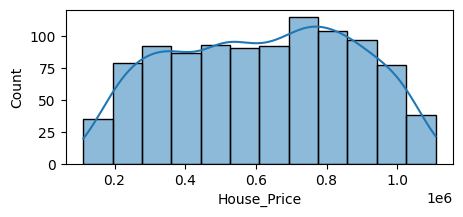

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(df,x='House_Price',kde=True)
plt.show()

**Note:** No visible skew or exponential growth, but we can still perform log transformation

In [ ]:
import numpy as np

df['Log_House_Price'] = np.log(df['House_Price'])

In [ ]:
df.drop(columns = ['House_Price'], inplace = True)

### **Feature Engineering**

In [ ]:
# split data for x and y
x = df.drop(columns=['Log_House_Price'])
y = df.loc[:,'Log_House_Price']

In [ ]:
#split data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### **Feature Scaling**

In [ ]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### **Model Training**

### Linear Regression Model

In [ ]:
model = LinearRegression()

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

Linear Regression is all about finiding the "best-fit" line, meaning we need to know **y = mx + c**

In [ ]:
# to know the slope (m)
model.coef_

array([0.46994959, 0.03140466, 0.01347381, 0.04444881, 0.03908808,
       0.00429261, 0.00512022])

In [ ]:
# to know the intercept (c)
model.intercept_

np.float64(13.229923498271374)

In [ ]:
y_pred

array([13.70480618, 12.98213068, 13.83543321, 14.00131016, 13.53537391,
       13.4460584 , 13.93869109, 13.72294254, 13.57256878, 13.82139076,
       13.48962108, 13.28570472, 12.46564867, 14.03066712, 13.06471375,
       12.4152215 , 12.92580428, 12.73638922, 13.4714718 , 12.75963066,
       13.53633152, 12.95877458, 13.33338613, 13.72781003, 12.91654494,
       12.82447476, 12.92063673, 12.8894939 , 12.41322886, 12.99977902,
       12.5842851 , 13.74253426, 13.54612284, 12.73716856, 12.96555949,
       13.51342842, 12.96784588, 13.13722463, 12.63692556, 12.35183603,
       12.63509203, 12.63192761, 13.03532948, 12.66247804, 14.10878263,
       13.98449233, 13.50224072, 13.57933233, 14.00787939, 13.35406596,
       12.60055766, 13.48317559, 13.60338653, 13.41860345, 13.08462929,
       13.59202086, 12.38940788, 12.69966117, 13.4112903 , 12.46528627,
       13.92233141, 12.78157303, 12.68239021, 13.03354352, 13.22224881,
       13.10212007, 12.96767177, 13.47893132, 13.85980784, 13.47

### **Model Evaluation**

1. R2 Score

In [ ]:
r2= r2_score(y_test,y_pred)
r2

0.9462493474741257

2. Adjusted R2 Score

In [ ]:
n= x_test.shape[0]
n # number of rows

200

In [ ]:
p= x_test.shape[1]
p #number of features

7

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9442896882674532

3. Mean Squared error

In [ ]:
mean_squared_error(y_test,y_pred)

0.012923132230239553

4. Mean absolute error

In [ ]:
mean_absolute_error(y_test,y_pred)

0.09078292767761205

5. Root Mean squared Error

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.11367995527022147)

6. Mean Absolute Percentage Error

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.0069598703388235724

### **KNN Regressor Model**

How to choose best value for K

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

error = []
for k in range(2,11):
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  error.append(rmse)
print(error)

[np.float64(0.22121593730266037), np.float64(0.19555027479747988), np.float64(0.18706860793231314), np.float64(0.18398466736114627), np.float64(0.182077865509207), np.float64(0.18344620706208817), np.float64(0.1853178104756023), np.float64(0.18367153909902165), np.float64(0.1815842707265892)]


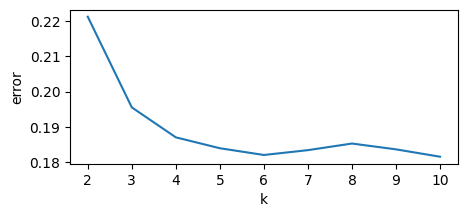

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

since the errors in 6 and 10 are lowest, we can either use 6 or 10 as k value

In [ ]:
model_knn = KNeighborsRegressor(n_neighbors=6)
model_knn.fit(x_train, y_train)
y_pred = model.predict(x_test)

**KNN Model Evaluation**

1. R2 Score

In [ ]:
r2_knn= r2_score(y_test,y_pred)
r2_knn

0.8628573916537281

2. Adjusted R2 Score

In [ ]:
n= x_test.shape[0]
p= x_test.shape[1]
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9442896882674532

3. Mean Squared error

In [ ]:
mean_squared_error(y_test,y_pred)

0.032972847375307236

4. Mean absolute error

In [ ]:
mean_absolute_error(y_test,y_pred)

0.1273013171429613

5. Root Mean squared Error

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.1815842707265892)

6. Mean Absolute Percentage Error

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.009864709226114392